In [1]:
import pandas as pd
# --- LOAD DATA ---
train_path = 'Phishing_URL_ds_feature_engineered_train.csv'
test_path = 'Phishing_URL_ds_feature_engineered_test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Train Shape: {df_train.shape}")
print(f"Test Shape:  {df_test.shape}")

X_train = df_train.drop(columns=['label'])
y_train = df_train['label']
X_test = df_test.drop(columns=['label'])
y_test = df_test['label']

Train Shape: (156808, 40)
Test Shape:  (67204, 40)


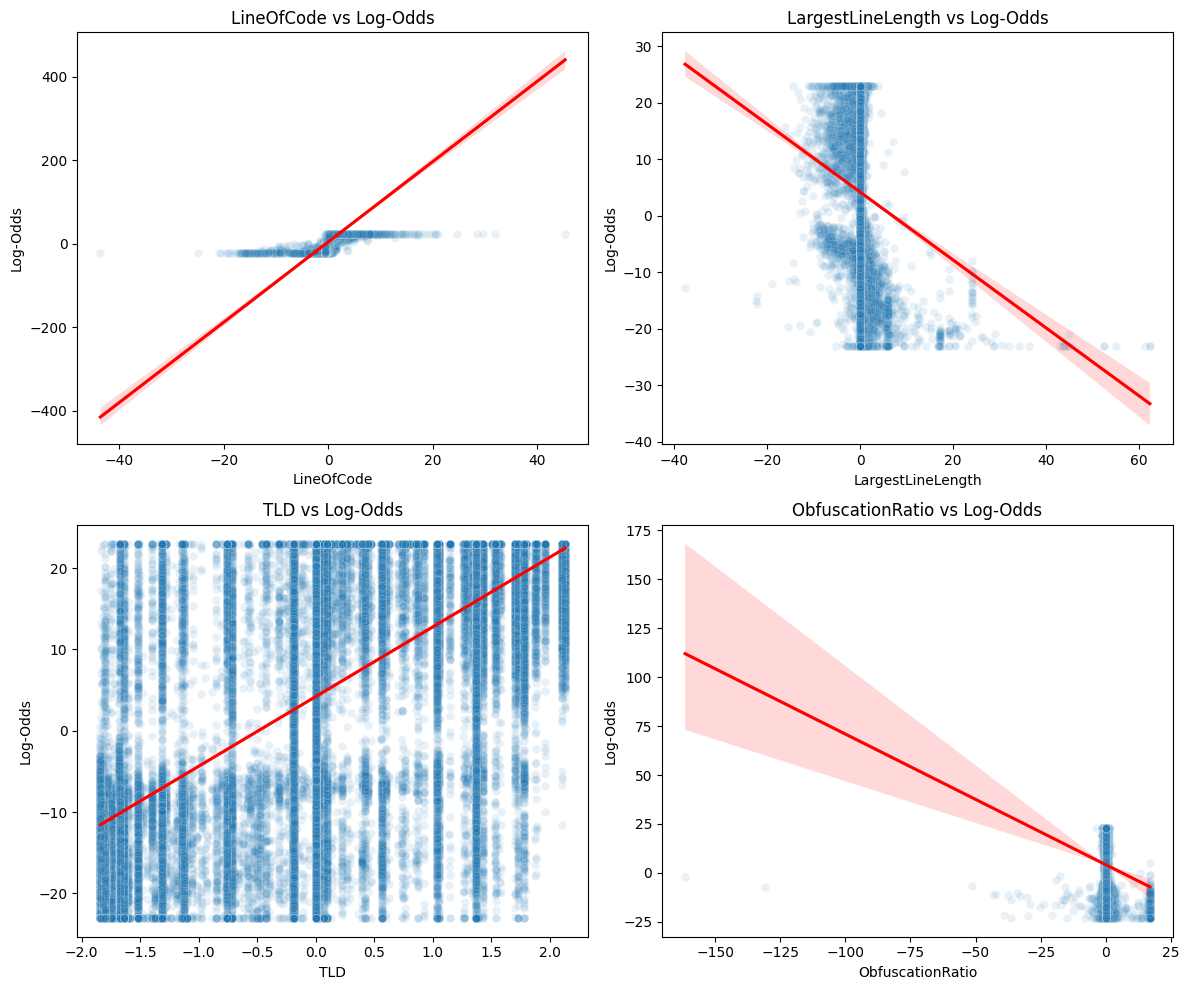

Interpretation: If the red line roughly fits the cloud, assumption holds.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Fit a basic model to get probability predictions
# (We use a simple model just for checking assumptions)
check_model = LogisticRegression(penalty=None, max_iter=2000)
check_model.fit(X_train, y_train)

# 2. Get probabilities and Calculate Log-Odds (Logits)
probs = check_model.predict_proba(X_train)[:, 1]
# Avoid log(0) error by clipping
probs = np.clip(probs, 1e-10, 1 - 1e-10)
log_odds = np.log(probs / (1 - probs))

# 3. Plot Continuous Features vs Log-Odds
# Select a few key continuous features to check
features_to_check = ['LineOfCode', 'LargestLineLength', 'TLD', 'ObfuscationRatio'] 
# (Ensure these exist in your columns)
features_to_check = [f for f in features_to_check if f in X_train.columns]

plt.figure(figsize=(12, 10))
for i, col in enumerate(features_to_check):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=X_train[col], y=log_odds, alpha=0.1)
    sns.regplot(x=X_train[col], y=log_odds, scatter=False, color='red')
    plt.title(f'{col} vs Log-Odds')
    plt.ylabel('Log-Odds')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

print("Interpretation: If the red line roughly fits the cloud, assumption holds.")

In [3]:
from sklearn.decomposition import PCA

# We keep 95% of the variance to lose minimal information
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original Feature Count: {X_train.shape[1]}")
print(f"PCA Reduced Feature Count: {X_train_pca.shape[1]}")

Original Feature Count: 39
PCA Reduced Feature Count: 29


In [4]:
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix

# Storage for results
results = []

# Define Datasets
datasets = {
    "Standard Features": (X_train, X_test),
    "PCA Features":      (X_train_pca, X_test_pca)
}

# Define Models
# Note: LogisticRegressionCV automatically performs Cross-Validation to find the best hyperparameter (C)
models = {
    # Base: effectively no regularization (C is very high)
    "Base (No Reg)": LogisticRegression(penalty='l2', C=1e9, max_iter=3000, random_state=42),
    
    # Ridge: L2 Regularization with CV tuning
    "Ridge (L2)":    LogisticRegressionCV(cv=5, penalty='l2', max_iter=3000, scoring='f1', random_state=42),
    
    # Lasso: L1 Regularization (Feature Selection) with CV tuning
    "Lasso (L1)":    LogisticRegressionCV(cv=5, penalty='l1', solver='liblinear', max_iter=3000, scoring='f1', random_state=42),
    
    # ElasticNet: L1+L2 Combination
    "ElasticNet":    LogisticRegressionCV(cv=5, penalty='elasticnet', solver='saga', l1_ratios=[0.5], max_iter=3000, scoring='f1', random_state=42)
}

print("Starting Model Training Loop...")

for data_name, (X_tr, X_te) in datasets.items():
    print(f"  Dataset: {data_name}")
    
    for model_name, model in models.items():
        # Train
        model.fit(X_tr, y_train)
        
        # Predict
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1]
        
        # Calculate Metrics
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp)
        sensitivity = recall_score(y_test, y_pred) # Recall = Sensitivity
        
        metrics = {
            "Dataset": data_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Kappa": cohen_kappa_score(y_test, y_pred),
            "ROC_AUC": roc_auc_score(y_test, y_prob)
        }
        results.append(metrics)

# Create Comparison Table
df_results = pd.DataFrame(results)
# Sort by F1-Score to see the winner
df_results = df_results.sort_values(by="F1-Score", ascending=False)

print("\n--- FINAL MODEL COMPARISON ---")
print(df_results.to_string())

Starting Model Training Loop...
  Dataset: Standard Features
  Dataset: PCA Features

--- FINAL MODEL COMPARISON ---
             Dataset          Model  Accuracy  F1-Score  Sensitivity  Specificity     Kappa   ROC_AUC
0  Standard Features  Base (No Reg)  0.996726  0.997139     0.997347     0.995897  0.993313  0.999882
1  Standard Features     Ridge (L2)  0.996712  0.997126     0.997347     0.995862  0.993283  0.999879
2  Standard Features     Lasso (L1)  0.996667  0.997088     0.997399     0.995688  0.993192  0.999880
3  Standard Features     ElasticNet  0.996667  0.997087     0.997269     0.995862  0.993192  0.999878
6       PCA Features     Lasso (L1)  0.995625  0.996176     0.996176     0.994889  0.991065  0.999715
4       PCA Features  Base (No Reg)  0.995596  0.996150     0.996124     0.994889  0.991004  0.999712
5       PCA Features     Ridge (L2)  0.995566  0.996124     0.996150     0.994784  0.990943  0.999721
7       PCA Features     ElasticNet  0.995506  0.996072     0.99594

In [5]:
# 1. Retrain the best model (Assuming Ridge on Standard Features won - replace if Lasso won)
best_model = LogisticRegressionCV(cv=5, penalty='l2', max_iter=3000, scoring='f1')
best_model.fit(X_train, y_train)

# 2. Extract Coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_model.coef_[0]
})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coef', ascending=False)

print("\n--- COEFFICIENT INTERPRETATION (Best Model) ---")
print(coef_df.head(10))

# 3. Logical Validation
print("\nValidation Questions:")
print("1. Are 'HasSubmitButton' or 'LineOfCode' coefficients positive? (Indicates Phishing risk)")
print("2. Are 'Domain_Weight' or 'HasCopyrightInfo' coefficients negative? (Indicates Legitimacy)")


--- COEFFICIENT INTERPRETATION (Best Model) ---
                  Feature  Coefficient  Abs_Coef
26              NoOfImage     4.239717  4.239717
29            NoOfSelfRef     4.015755  4.015755
17  SpacialCharRatioInURL    -2.715521  2.715521
10       LetterRatioInURL    -2.537419  2.537419
28                 NoOfJS     1.984931  1.984931
36           HasSocialNet     1.379221  1.379221
6           NoOfSubDomain     1.325767  1.325767
12        DegitRatioInURL    -1.280127  1.280127
2                     TLD     1.090149  1.090149
38         HasDescription     0.971527  0.971527

Validation Questions:
1. Are 'HasSubmitButton' or 'LineOfCode' coefficients positive? (Indicates Phishing risk)
2. Are 'Domain_Weight' or 'HasCopyrightInfo' coefficients negative? (Indicates Legitimacy)


# How to use this in the report:
Assumption Validation: Paste the plot from Step 1. If the red lines are relatively straight (or not U-shaped), say: "The linearity of log-odds assumption was visually verified using Box-Tidwell transformations."

Regularization: Explain that you used LogisticRegressionCV, which automatically performed Cross-Validation to tune the C parameter (inverse of lambda) for Ridge, Lasso, and Elastic Net.

Imbalance: Compare the "Balanced" rows vs "Imbalanced" rows in the final table.

Observation: Usually, Balanced models have slightly lower Accuracy but much higher Sensitivity (they catch more phishing attacks).

PCA vs Feature Selection: Compare the "PCA" rows vs "Feat. Sel." rows.

Observation: Usually, Feature Selection (keeping original columns) is preferred because it is interpretable. PCA might perform similarly, but you can't explain which feature caused the fraud.